<a href="https://colab.research.google.com/github/IrineuBovoJunior398/P-S_GRADUA-O_IA_UTFPR/blob/main/C%C3%B3pia_de_DATASET_IRIS_TREINO_TESTE_NORMALIZA%C3%87%C3%83O_CODIFICA%C3%87%C3%83O_TREINAR_PREDI%C3%87%C3%95ES_ACUR%C3%81CIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Acurácia no treino: 0.9714
Acurácia no teste: 1.0000

Relatório de classificação no treino:
              precision    recall  f1-score   support

      setosa       0.97      1.00      0.98        31
  versicolor       0.97      0.95      0.96        37
   virginica       0.97      0.97      0.97        37

    accuracy                           0.97       105
   macro avg       0.97      0.97      0.97       105
weighted avg       0.97      0.97      0.97       105


Relatório de classificação no teste:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



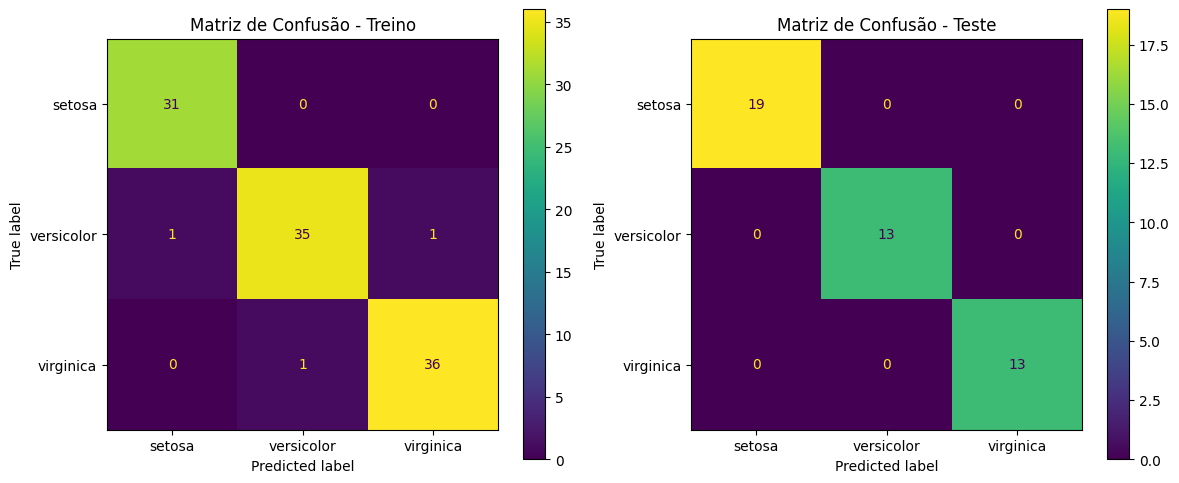

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Carregar o dataset Iris
dados = load_iris()
X = dados.data
y = dados.target

# Dividir em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalizar X com StandardScaler
scaler = StandardScaler()
X_treino_normalizado = scaler.fit_transform(X_treino)
X_teste_normalizado = scaler.transform(X_teste)

# Codificar y usando OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
y_treino_encoded = encoder.fit_transform(y_treino.reshape(-1, 1))
y_teste_encoded = encoder.transform(y_teste.reshape(-1, 1))

# Treinar o MLPClassifier
modelo = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1000, random_state=42)
modelo.fit(X_treino_normalizado, y_treino_encoded)

# Gerar previsões
previsoes_treino = modelo.predict(X_treino_normalizado)
previsoes_teste = modelo.predict(X_teste_normalizado)

# Converter saídas one-hot para rótulos usando argmax
y_treino_pred = np.argmax(previsoes_treino, axis=1)
y_teste_pred = np.argmax(previsoes_teste, axis=1)

# Avaliar com accuracy_score
acc_treino = accuracy_score(y_treino, y_treino_pred)
acc_teste = accuracy_score(y_teste, y_teste_pred)
print(f'Acurácia no treino: {acc_treino:.4f}')
print(f'Acurácia no teste: {acc_teste:.4f}')

# Imprimir classification_report
print('\nRelatório de classificação no treino:')
print(classification_report(y_treino, y_treino_pred, target_names=dados.target_names))
print('\nRelatório de classificação no teste:')
print(classification_report(y_teste, y_teste_pred, target_names=dados.target_names))

# Gerar gráficos das matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusão para treino
ConfusionMatrixDisplay.from_predictions(y_treino, y_treino_pred, ax=axes[0], display_labels=dados.target_names)
axes[0].set_title('Matriz de Confusão - Treino')

# Matriz de confusão para teste
ConfusionMatrixDisplay.from_predictions(y_teste, y_teste_pred, ax=axes[1], display_labels=dados.target_names)
axes[1].set_title('Matriz de Confusão - Teste')

plt.tight_layout()
plt.show()